## Read Dataset from Kaggle

In [ ]:
import kagglehub

path = kagglehub.dataset_download(
    "nikhil7280/student-performance-multiple-linear-regression")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'student-performance-multiple-linear-regression' dataset.
Path to dataset files: /kaggle/input/student-performance-multiple-linear-regression


In [ ]:
import os

print(os.listdir(path))

file_path = os.path.join(path ,'Student_Performance.csv')
df = pd.read_csv(file_path)

['Student_Performance.csv']


In [ ]:
df.shape
df.dtypes
df.head()
df.isnull().sum()
df.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


## import library

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (mean_absolute_error ,mean_squared_error,r2_score)

## Correlation matrix

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(10, 6))

sns.heatmap(
    df.select_dtypes(include="number").corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

## Remove extra spaces from categorical values

In [ ]:
df.columns = df.columns.str.strip()

# Remove extra spaces from categorical values
df["Extracurricular Activities"] = (
    df["Extracurricular Activities"]
    .astype(str)
    .str.strip()
    .map({
        "Yes": 1,
        "No": 0
    })
)

df = df.dropna()

In [ ]:
X = df.drop("Performance Index", axis=1)
y = df["Performance Index"]

X_train, X_test, y_train, y_test = train_test_split (X ,y ,test_size=0.2,random_state=42)


## Build Polynomial Regression Model

In [ ]:
model = Pipeline([
    (
        "polynomial_features",
        PolynomialFeatures(
            degree=2,
            include_bias=False
        )
    ),
    (
        "linear_regression",
        LinearRegression()
    )
])

##Train Model

In [ ]:
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


##Evaluate Model

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print("Model Performance")
print("----------------------------")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")


Model Performance
----------------------------
MAE  : 1.6115
MSE  : 4.0806
RMSE : 2.0201
R²   : 0.9890


##Actual vs Predicted Plot

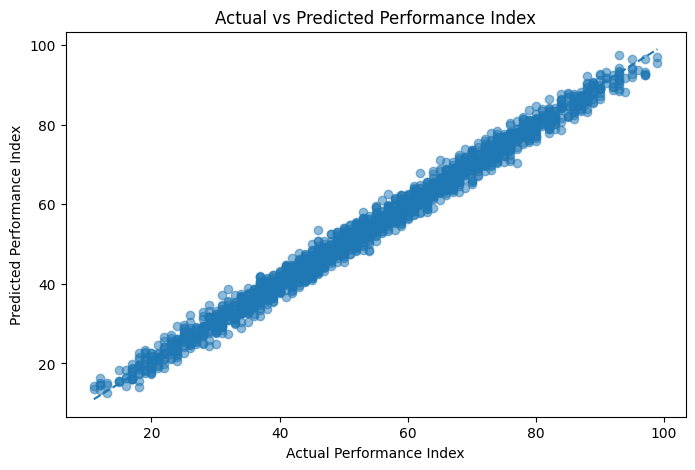

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.title("Actual vs Predicted Performance Index")
plt.xlabel("Actual Performance Index")
plt.ylabel("Predicted Performance Index")

plt.show()